# **Carga de datos y Analisis exploratorio**

In [1]:
# Se realiza la carga de los datos desde un archivo CSV utilizando la biblioteca pandas. 
# El archivo se encuentra en la ruta "../data/raw/Nike_Sales_Uncleaned.csv".

import pandas as pd

df = pd.read_csv("../data/raw/retail_store_sales.csv")
pd.set_option("display.max_columns", 60)

In [2]:
# Inspección visual del conjunto de datos para obtener una idea general de su estructura y contenido.
# Esto nos permite identificar rápidamente las columnas presentes, el tipo de datos que contienen 
# y algunas de las primeras filas del conjunto de datos.

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [3]:
# Revisamos la forma del conjunto de datos, es decir, el número de filas y columnas que contiene. 
# Esto nos da una idea de la cantidad de registros y variables presentes en el conjunto de datos.

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 12575
Número de columnas: 11


In [4]:
# Revisamos la información de las columnas del conjunto de datos, incluyendo el tipo de datos de cada columna,
# y la cantidad de valores no nulos.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [5]:
# Revisamos las estadisticas descriptivas del conjunto de datos, incluyendo medidas como la media,

df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [6]:
# Revisamos la cantidad de valores nulos en cada columna del conjunto de datos. 
# Esto nos permite identificar si hay columnas con datos faltantes y cuántos valores faltan en cada una de ellas.

df[
    [
        "Item",
        "Price Per Unit",
        "Quantity",
        "Total Spent",
        "Discount Applied"
    ]
].isna().sum()

Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Discount Applied    4199
dtype: int64

In [7]:
# Revisamos las unidades de negocio del conjunto de datos, para analisis posteriores.

df['Category'].unique()

array(['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food',
       'Furniture', 'Electric household essentials',
       'Computers and electric accessories'], dtype=object)

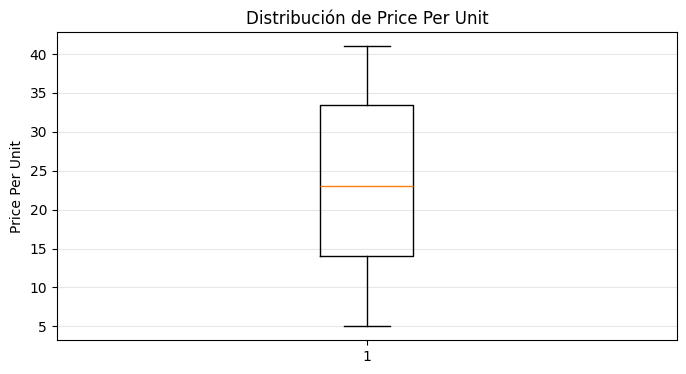

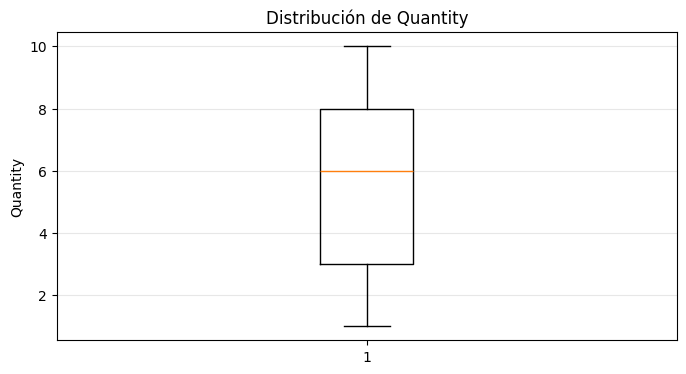

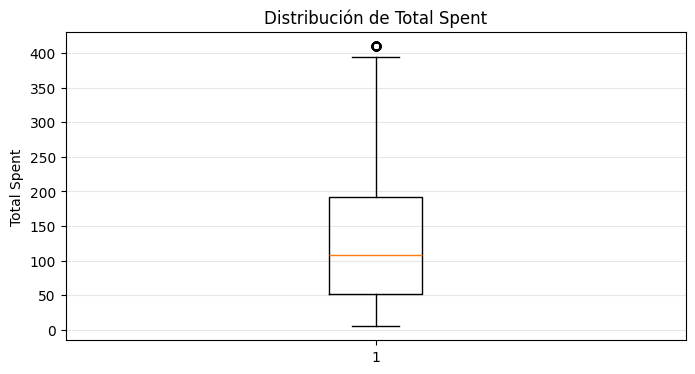

In [8]:
# Objetivo:
# Visualizar la distribución de las variables numéricas para identificar
# posibles valores atípicos (outliers) antes de decidir cómo tratar sus nulos.

import matplotlib.pyplot as plt

numeric_columns = [
    'Price Per Unit',
    'Quantity',
    'Total Spent'
]

# Generar un boxplot independiente para cada variable numérica.
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f'Distribución de {column}')
    plt.ylabel(column)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [9]:
# Objetivo:
# Comprobar si Total Spent mantiene una relación consistente con
# Price Per Unit × Quantity en los registros donde las tres variables existen.

numeric_complete = df[
    ['Price Per Unit', 'Quantity', 'Total Spent']
].dropna().copy()

# Calcular el total esperado a partir del precio unitario y la cantidad.
numeric_complete['Calculated Total'] = (
    numeric_complete['Price Per Unit'] *
    numeric_complete['Quantity']
)

# Comparar el total calculado con el total registrado.
numeric_complete['Difference'] = (
    numeric_complete['Total Spent'] -
    numeric_complete['Calculated Total']
)

# Mostrar un resumen de las diferencias encontradas.
numeric_complete['Difference'].describe()

count    11362.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Difference, dtype: float64

In [10]:
# Objetivo:
# Identificar las combinaciones de valores nulos entre las tres variables
# numéricas para determinar cuáles pueden reconstruirse matemáticamente.

numeric_null_patterns = (
    df[['Price Per Unit', 'Quantity', 'Total Spent']]
    .isna()
    .value_counts()
    .rename('Records')
    .reset_index()
)

# Mostrar cada patrón de nulos y la cantidad de registros afectados.
numeric_null_patterns

,Price Per Unit,Quantity,Total Spent,Records
0,False,False,False,11362
1,True,False,False,609
2,False,True,True,604


In [11]:
# Objetivo:
# Revisar la frecuencia de cada cantidad observada para determinar
# cuál es el valor más representativo antes de imputar los valores faltantes.

quantity_distribution = (
    df['Quantity']
    .value_counts()
    .sort_index()
)

quantity_distribution

Quantity
1.0     1147
2.0     1164
3.0     1224
4.0     1155
5.0     1228
6.0     1220
7.0     1227
8.0     1226
9.0     1148
10.0    1232
Name: count, dtype: int64

## Cierre del análisis exploratorio

El análisis exploratorio permitió comprender la estructura, calidad y características principales del dataset antes de aplicar transformaciones.

### Principales hallazgos

- El dataset contiene **12.575 registros y 11 columnas**.
- `Transaction ID` identifica de forma única cada transacción.
- Existen **25 clientes**, **8 categorías de negocio**, 3 métodos de pago y 2 tipos de ubicación.
- La columna `Transaction Date` contiene fechas válidas, pero actualmente se encuentra almacenada como texto.
- Se identificaron valores nulos principalmente en `Item`, `Price Per Unit`, `Quantity`, `Total Spent` y `Discount Applied`.
- Las variables `Price Per Unit` y `Quantity` no presentan valores atípicos relevantes.
- `Total Spent` presenta un único valor identificado como atípico mediante el boxplot. Sin embargo, este valor es coherente con los valores máximos observados de `Price Per Unit` y `Quantity`, por lo que no se considera un error y no será eliminado.
- Se comprobó que, para los **11.362 registros completos**, se cumple exactamente la relación:

  `Total Spent = Price Per Unit × Quantity`

### Decisiones para la etapa de limpieza

A partir de los hallazgos anteriores, se establecieron las siguientes reglas:

1. Los **609 valores faltantes de `Price Per Unit`** serán reconstruidos mediante:

   `Price Per Unit = Total Spent / Quantity`

2. Los **604 registros con `Quantity` y `Total Spent` faltantes** no pueden reconstruirse directamente a partir de las variables disponibles. Para `Quantity` se utilizará la mediana observada, cuyo valor es **6**.

3. Una vez imputada `Quantity`, `Total Spent` será calculado mediante:

   `Total Spent = Price Per Unit × Quantity`

4. No se eliminará el único valor atípico de `Total Spent`, ya que es compatible con la relación entre precio, cantidad y total.

5. Los valores nulos de las variables categóricas serán tratados de acuerdo con su significado, evitando imputaciones arbitrarias mediante la moda.

### Transición a la etapa de limpieza

Con el diagnóstico exploratorio finalizado, se continuará con la implementación de las reglas definidas en el script:

`scripts/02_limpieza_enriquecimiento.py`

En esta etapa se aplicarán las transformaciones, imputaciones y validaciones necesarias para obtener un dataset procesado y consistente que posteriormente podrá ser cargado en PostgreSQL.